### TP0

**Nom:** machhoul <br>
**Prenom:** ilyas <br> 

# 1. Régression Linéaire Simple Numpy



## 1.1. Dataset
Génération de données aléatoires avec une tendance linéaire avec make_regression: on a un dataset $(x, y)$ qui contient 100 exemples, et une seule variable $x$. Note: chaque fois que la cellule est executée, des données différentes sont générer. Utiliser np.random.seed(0) pour reproduire le meme Dataset a chaque fois.

In [ ]:
import numpy as np
#from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

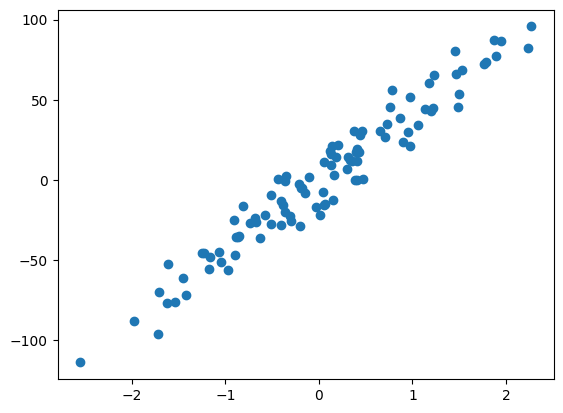

In [2]:
np.random.seed(0) # pour toujours reproduire le meme dataset
x, y = make_regression(n_samples=100, n_features=1, noise=10)
plt.scatter(x, y) # afficher les résultats. X en abscisse et y en ordonnée

Important: vérifier les dimensions de x et y. On remarque que y n'a pas les dimensions (100, 1). On corrige le probleme avec np.reshape

In [3]:
# Afficher la taille de x et y
print(x.shape)
print(y.shape)

(100, 1)
(100,)


In [4]:
# redimensionner y 
y = y.reshape(y.shape[0], 1)

print(y.shape)

(100, 1)


Création de la matrice X qui contient la colonne de Biais. Pour ca, on colle l'un contre l'autre le vecteur x et un vecteur 1 (avec np.ones) de dimension égale a celle de x

In [5]:
X = np.hstack((x, np.ones(x.shape)))
print(X.shape)

(100, 2)


In [6]:
np.random.seed(0) # pour produire toujours le meme vecteur theta aléatoire
theta = np.random.randn(2, 1)
theta

array([[1.76405235],
       [0.40015721]])

## 1.2. Modele Linéaire
On implémente un modele F = X.theta

In [7]:
# creer une fonction qui prend en entrée X et theta et qui retourne les prédictions
def model (X,theta):
    return X.dot(theta)

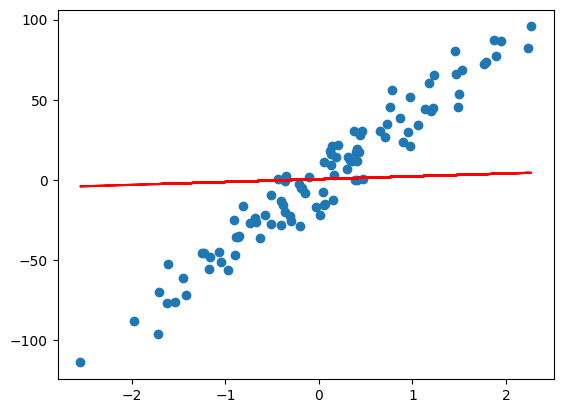

In [8]:
# Afficher les prédictions
plt.scatter(x, y)
plt.plot(x, model(X, theta), c='r')

## 1.3. Fonction Cout :  Erreur Quadratique moyenne
On mesure les erreurs du modele sur le Dataset X, y en implémenterl'erreur quadratique moyenne,  **Mean Squared Error (MSE)** en anglais.

In [9]:
# creer une fonction qui calcule le coût de la régression linéaire
def cost_function(X, y, theta):
    m = len(y)
    return 1/(2*m) * np.sum((model(X, theta) - y)**2)

In [10]:
# calculer le coût de la régression linéaire
cost_function(X, y, theta)


np.float64(905.6306841935502)

## 1.4. Gradients et Descente de Gradient
On implémente la formule du gradient pour la **MSE**


In [ ]:
def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(model(X, theta) - y)
#model(X,theha) et y son deux vecteur colonne 
# T transpose 
# X matrice 2 colonne et plusieur ligne 
# return un vecteur 1 colonne de 2 ligne 

In [ ]:
def gradient_descent(X, y, theta, learning_rate, n_iterations): # learning_rate c'est le nbr des pas
    cost_history = np.zeros(n_iterations) #  creation d'un tab de stockage pour enregistre l'evolution du cout de modele
    for i in range(0, n_iterations):
        theta = theta - learning_rate * grad(X, y, theta)# mise a jour du parametre theta (formule de gredient descent)
        cost_history[i] = cost_function(X, y, theta)# on enrgistre la valeur du cout au tour i dans cost_history
        #cost_fonction est la fonction d'error
    return theta, cost_history

## 1.5. Phase d'entrainement
On définit un **nombre d'itérations**, ainsi qu'un **pas d'apprentissage $\alpha$**



In [13]:
n_iterations = 1000
learning_rate = 0.01

theta_final, cost_history = gradient_descent(X, y, theta, learning_rate, n_iterations)

In [14]:
theta_final

array([[42.61765864],
       [-0.81309274]])

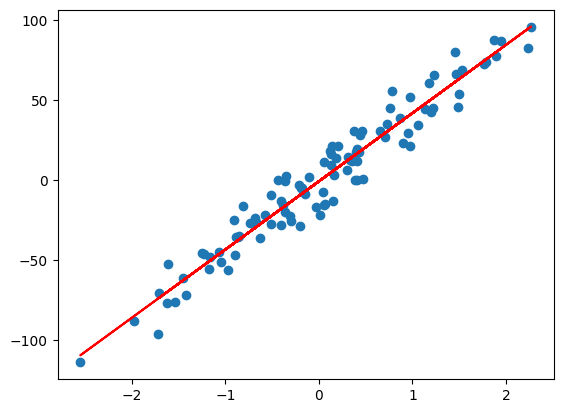

In [21]:
predictions = model(X, theta_final)
plt.scatter(x, y)
plt.plot(x, predictions, c='r')

## 1.6. Courbes d'apprentissage


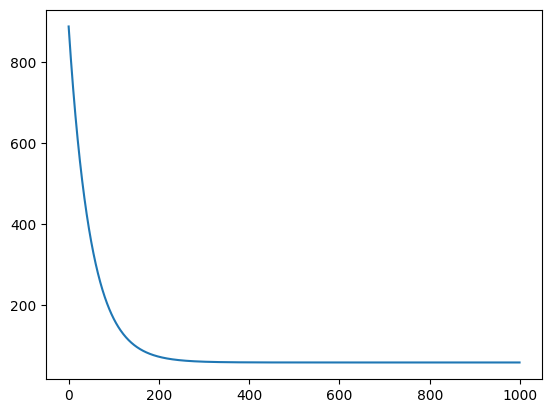

In [16]:
plt.plot(range(n_iterations), cost_history)

## 1.7. Evaluation finale
Pour évaluer la réelle performance de notre modele on peut utiliser le **coefficient de détermination**, <br>
aussi connu sous le nom $R^2$. 

In [17]:
def coef_determination(y, pred):
    u = ((y - pred)**2).sum()
    v = ((y - y.mean())**2).sum()
    return 1 - u/v

In [19]:
coef_determination(y, predictions)

np.float64(0.9417294706504984)

# 2. Régression Linéaire Polynomiale Numpy

## 2.1. dataset

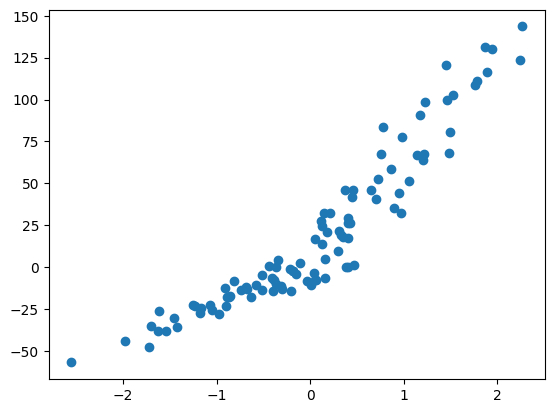

In [22]:
np.random.seed(0) # permet de reproduire l'aléatoire

x, y = make_regression(n_samples=100, n_features=1, noise = 10) # creation d'un dataset (x, y) linéaire
y = y + abs(y/2) # modifie les valeurs de y pour rendre le dataset non-linéaire

plt.scatter(x, y) # afficher les résultats. x en abscisse et y en ordonnée

In [23]:
# Verification des dimensions
print(x.shape)
print(y.shape)

# redimensionner y
y = y.reshape(y.shape[0], 1)
print(y.shape)

(100, 1)
(100,)
(100, 1)


In [24]:
# Création de la matrice X, inclut le Biais
X = np.hstack((x, np.ones(x.shape)))
X = np.hstack((x**2, X)) # ajoute le vecteur x^2 a la gauche de la matrice X

print(X.shape)
print(X[:10])

(100, 3)
[[ 0.12927848 -0.35955316  1.        ]
 [ 0.95382381  0.97663904  1.        ]
 [ 0.1618788   0.40234164  1.        ]
 [ 0.66120688 -0.81314628  1.        ]
 [ 0.78816353 -0.88778575  1.        ]
 [ 0.19701457  0.44386323  1.        ]
 [ 0.95507205 -0.97727788  1.        ]
 [ 0.18346819  0.42833187  1.        ]
 [ 0.04337847  0.20827498  1.        ]
 [ 0.09706498 -0.31155253  1.        ]]


In [25]:
# Initialisation du vecteur theta aléatoire, avec 3 éléments (car X a trois colonnes)
theta = np.random.randn(3, 1)
theta

array([[-0.63743703],
       [-0.39727181],
       [-0.13288058]])

In [26]:
cost_function(X, y, theta)

np.float64(1328.6654828872622)

## 2.2 Phase d'entrainement
On définit un **nombre d'itérations**, ainsi qu'un **pas d'apprentissage $\alpha$**, et c'est partit !



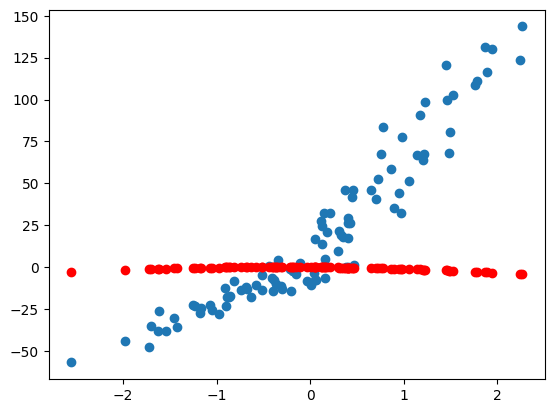

In [27]:
plt.scatter(x, y)
plt.scatter(x, model(X, theta), c='r')

In [ ]:
n_iterations = 1000
learning_rate = 0.01
# la matrice X contient les trois varaible x^2 et x et 1 !!!!

theta_final, cost_history = gradient_descent(X, y, theta, learning_rate, n_iterations)

In [30]:
theta_final

array([[ 8.60077615],
       [42.23116732],
       [ 8.18143081]])

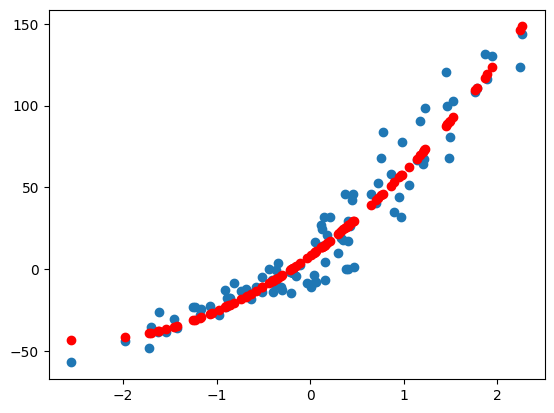

In [31]:
plt.scatter(x, y)
plt.scatter(x, model(X, theta_final), c='r')

## 2.3 Evaluation finale

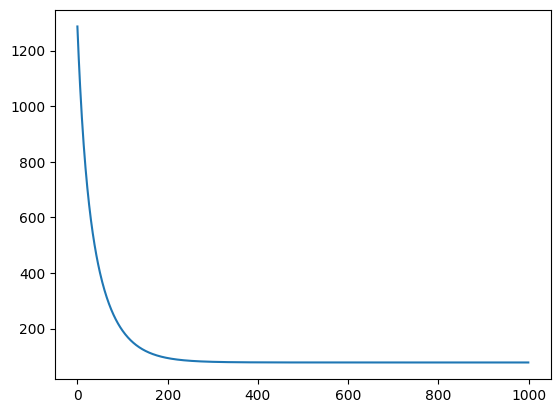

In [32]:
# afficher l'évolution du coût au cours des itérations
plt.plot(range(n_iterations), cost_history)


In [34]:
coef_determination(y, model(X, theta_final))

np.float64(0.9287186469389942)